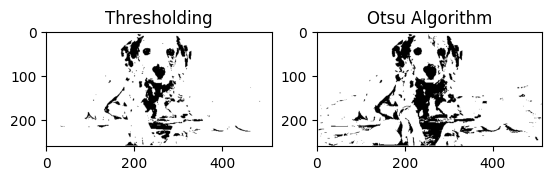

In [4]:
import cv2 as cv
import matplotlib.pyplot as An
import numpy as np

# Đọc ảnh theo mẫu yêu cầu [cite: 4]
img = cv.imread('hinh1.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# 1. Thresholding cơ bản
ret, thresh1 = cv.threshold(img_gray, 127, 255, cv.THRESH_BINARY)

# 2. Otsu Algorithm (Dùng cho ảnh vân tay)
ret_otsu, thresh_otsu = cv.threshold(img_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

An.subplot(1, 2, 1), An.imshow(thresh1, 'gray'), An.title('Thresholding')
An.subplot(1, 2, 2), An.imshow(thresh_otsu, 'gray'), An.title('Otsu Algorithm')
An.show()

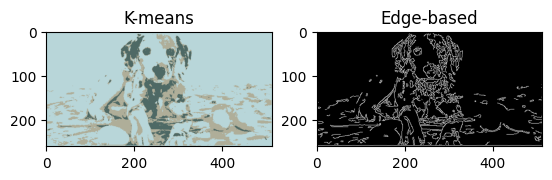

In [6]:
# 3. K-means Clustering
Z = img.reshape((-1,3))
Z = np.float32(Z)
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3
ret, label, center = cv.kmeans(Z, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)
center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((img.shape))

# 4. Edge-based Segmentation (Canny)
edges = cv.Canny(img_gray, 100, 200)

An.subplot(1, 2, 1), An.imshow(cv.cvtColor(res2, cv.COLOR_BGR2RGB)), An.title('K-means')
An.subplot(1, 2, 2), An.imshow(edges, 'gray'), An.title('Edge-based')
An.show()